# TCIA Imaging EDA — NSCLC-Radiomics Cohort and DICOM Inspection

This notebook explores the imaging data from **The Cancer Imaging Archive (TCIA)** for the NSCLC TNM
staging project. It focuses on the **NSCLC-Radiomics** collection (422 patients, CT scans with RTSTRUCT
tumour/organ contours and TNM/overall-stage labels in `Lung1_clinical.csv`), with a brief check on the
**NSCLC-Radiogenomics** collection for completeness. Goals: (1) understand the TNM stage, histology, and
survival distributions that form the ground truth for staging, (2) verify the DICOM folder structure and
cross-reference imaging folders with clinical labels, (3) inspect a sample patient's CT series and RTSTRUCT
contours in detail, and (4) survey scan dimensions, voxel spacing, and RTSTRUCT/GTV availability across the
cohort. Expected outputs: a TNM stage distribution (flagging class imbalance), a matched
imaging-clinical cohort CSV, sample CT/RTSTRUCT metadata, aggregate scan-geometry statistics to inform
preprocessing, and an RTSTRUCT availability table to inform Vision Agent sample selection.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import random
import warnings

import pydicom
import SimpleITK as sitk
from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

In [2]:
DATA_ROOT = Path('../../data/raw')
RADIOMICS_DIR = DATA_ROOT / 'NSCLC-Radiomics'
RADIOGENOMICS_DIR = DATA_ROOT / 'NSCLC-Radiogenomics'
LUNG1_CLINICAL = DATA_ROOT / 'Lung1_clinical.csv'

for name, path in [('DATA_ROOT', DATA_ROOT), ('RADIOMICS_DIR', RADIOMICS_DIR),
                    ('RADIOGENOMICS_DIR', RADIOGENOMICS_DIR), ('LUNG1_CLINICAL', LUNG1_CLINICAL)]:
    print(f"{name}: {path} -> exists: {path.exists()}")

print()
for name, d in [('NSCLC-Radiomics', RADIOMICS_DIR), ('NSCLC-Radiogenomics', RADIOGENOMICS_DIR)]:
    n_folders = len([p for p in d.iterdir() if p.is_dir()])
    print(f"{name}: {n_folders} patient folders")

DATA_ROOT: ../../data/raw -> exists: True
RADIOMICS_DIR: ../../data/raw/NSCLC-Radiomics -> exists: True
RADIOGENOMICS_DIR: ../../data/raw/NSCLC-Radiogenomics -> exists: True
LUNG1_CLINICAL: ../../data/raw/Lung1_clinical.csv -> exists: True

NSCLC-Radiomics: 422 patient folders
NSCLC-Radiogenomics: 211 patient folders


## Lung1 Clinical Data — Ground Truth Labels

In [3]:
clinical = pd.read_csv(LUNG1_CLINICAL)

print(f"shape: {clinical.shape}")
print(f"columns: {list(clinical.columns)}")
print()
print(clinical.dtypes)
print()
print("This file contains TNM stage components (clinical.T.Stage, Clinical.N.Stage, Clinical.M.Stage),")
print("the Overall.Stage, Histology, and survival outcome (Survival.time, deadstatus.event)")
print("for the NSCLC-Radiomics patients.")

display(clinical.head(10))
display(clinical.describe())

shape: (422, 10)
columns: ['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage', 'Overall.Stage', 'Histology', 'gender', 'Survival.time', 'deadstatus.event']

PatientID            object
age                 float64
clinical.T.Stage    float64
Clinical.N.Stage      int64
Clinical.M.Stage      int64
Overall.Stage        object
Histology            object
gender               object
Survival.time         int64
deadstatus.event      int64
dtype: object

This file contains TNM stage components (clinical.T.Stage, Clinical.N.Stage, Clinical.M.Stage),
the Overall.Stage, Histology, and survival outcome (Survival.time, deadstatus.event)
for the NSCLC-Radiomics patients.


,PatientID,age,clinical.T.Stage,Clinical.N.Stage,Clinical.M.Stage,Overall.Stage,Histology,gender,Survival.time,deadstatus.event
0,LUNG1-001,78.7515,2.0,3,0,IIIb,large cell,male,2165,1
1,LUNG1-002,83.8001,2.0,0,0,I,squamous cell carcinoma,male,155,1
2,LUNG1-003,68.1807,2.0,3,0,IIIb,large cell,male,256,1
3,LUNG1-004,70.8802,2.0,1,0,II,squamous cell carcinoma,male,141,1
4,LUNG1-005,80.4819,4.0,2,0,IIIb,squamous cell carcinoma,male,353,1
5,LUNG1-006,73.8864,3.0,1,0,IIIa,squamous cell carcinoma,male,173,1
6,LUNG1-007,81.5288,2.0,2,0,IIIa,squamous cell carcinoma,male,137,1
7,LUNG1-008,71.6660,2.0,2,0,IIIa,adenocarcinoma,male,77,1
8,LUNG1-009,56.1342,2.0,2,0,IIIa,squamous cell carcinoma,male,131,1
9,LUNG1-010,71.0554,4.0,3,0,IIIb,squamous cell carcinoma,female,2119,0


,age,clinical.T.Stage,Clinical.N.Stage,Clinical.M.Stage,Survival.time,deadstatus.event
count,400.000000,421.000000,422.000000,422.000000,422.000000,422.000000
mean,68.036500,2.475059,1.355450,0.030806,988.857820,0.883886
std,10.083498,1.130727,1.218116,0.294847,1035.567789,0.320742
min,33.684900,1.000000,0.000000,0.000000,10.000000,0.000000
25%,61.234800,2.000000,0.000000,0.000000,261.000000,1.000000
50%,68.583400,2.000000,2.000000,0.000000,545.500000,1.000000
75%,75.814475,4.000000,2.000000,0.000000,1397.000000,1.000000
max,91.704300,5.000000,4.000000,3.000000,4454.000000,1.000000


## TNM Stage Distribution

TNM staging (Tumour, Node, Metastasis) is the **ground truth label** for our staging task. We need to
understand the class balance for T, N, M, and Overall Stage: if heavily imbalanced (e.g. very few
Stage I or Stage IV cases), we will need stratified train/val/test splits and likely class-weighted loss
or oversampling for the Guideline Logic Agent's evaluation in later weeks.

All columns: ['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage', 'Overall.Stage', 'Histology', 'gender', 'Survival.time', 'deadstatus.event']



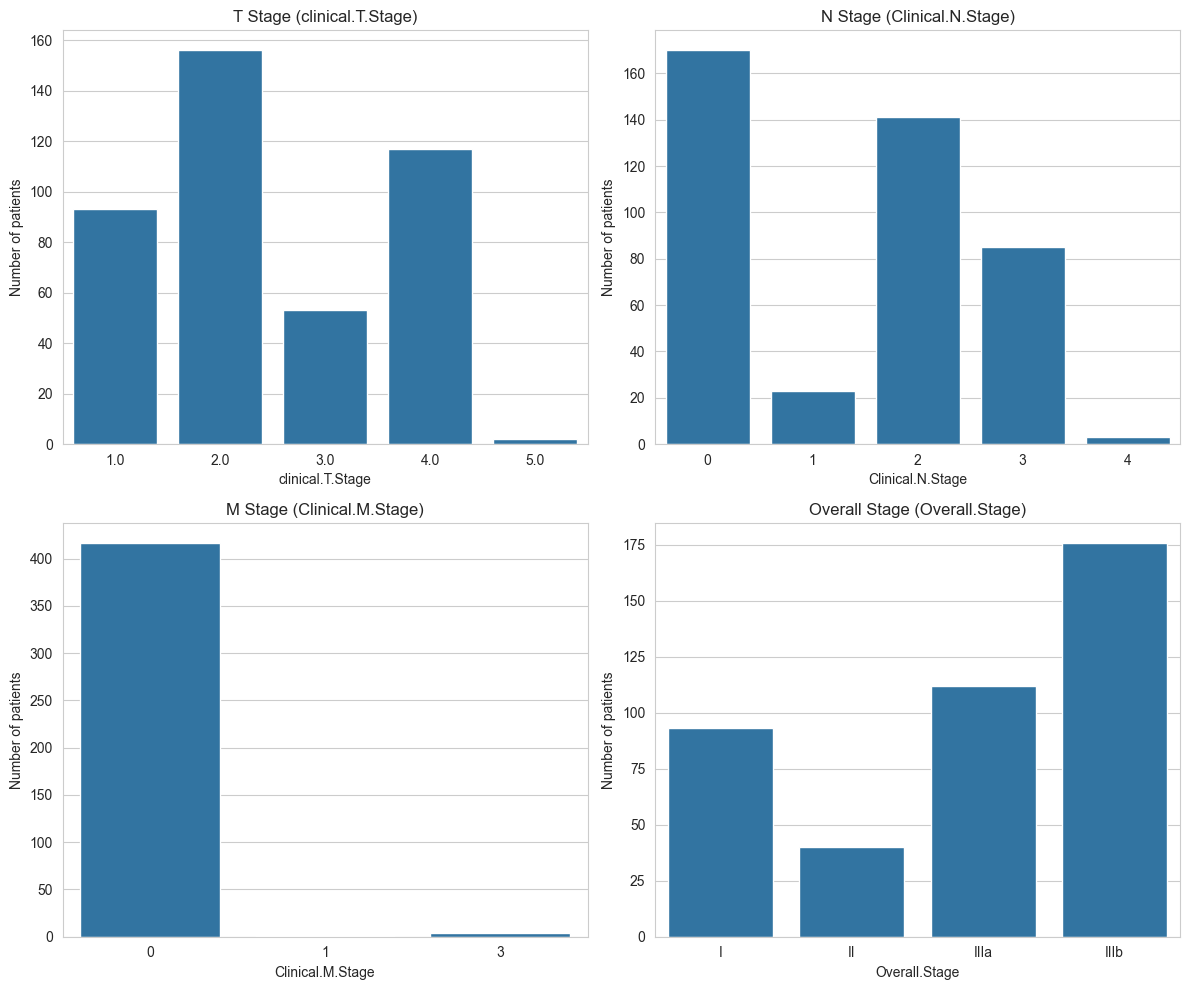

--- T Stage (clinical.T.Stage) ---
clinical.T.Stage
2.0    156
4.0    117
1.0     93
3.0     53
5.0      2
NaN      1
Name: count, dtype: int64
Missing: 1

--- N Stage (Clinical.N.Stage) ---
Clinical.N.Stage
0    170
2    141
3     85
1     23
4      3
Name: count, dtype: int64
Missing: 0

--- M Stage (Clinical.M.Stage) ---
Clinical.M.Stage
0    417
3      4
1      1
Name: count, dtype: int64
Missing: 0

--- Overall Stage (Overall.Stage) ---
Overall.Stage
IIIb    176
IIIa    112
I        93
II       40
NaN       1
Name: count, dtype: int64
Missing: 1



In [4]:
print("All columns:", list(clinical.columns))
print()

stage_cols = {
    'T Stage': 'clinical.T.Stage',
    'N Stage': 'Clinical.N.Stage',
    'M Stage': 'Clinical.M.Stage',
    'Overall Stage': 'Overall.Stage',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (title, col) in zip(axes.flat, stage_cols.items()):
    order = [str(v) for v in sorted(clinical[col].dropna().unique(), key=str)]
    sns.countplot(x=clinical[col].astype(str), order=order, ax=ax)
    ax.set_title(f'{title} ({col})')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.show()

for title, col in stage_cols.items():
    print(f"--- {title} ({col}) ---")
    print(clinical[col].value_counts(dropna=False))
    print(f"Missing: {clinical[col].isna().sum()}")
    print()

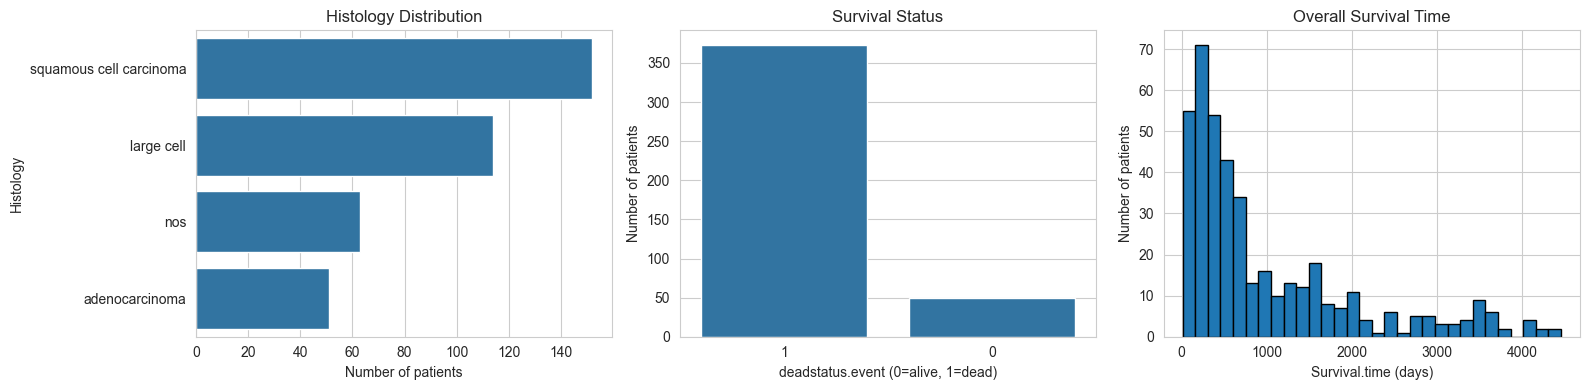

Histology value counts:
Histology
squamous cell carcinoma    152
large cell                 114
nos                         63
adenocarcinoma              51
NaN                         42
Name: count, dtype: int64

Survival status value counts (0=alive, 1=dead):
deadstatus.event
1    373
0     49
Name: count, dtype: int64

Survival.time summary (days):
count     422.000000
mean      988.857820
std      1035.567789
min        10.000000
25%       261.000000
50%       545.500000
75%      1397.000000
max      4454.000000
Name: Survival.time, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

order = clinical['Histology'].value_counts().index
sns.countplot(y=clinical['Histology'], order=order, ax=axes[0])
axes[0].set_title('Histology Distribution')
axes[0].set_xlabel('Number of patients')

sns.countplot(x=clinical['deadstatus.event'].astype(str), ax=axes[1])
axes[1].set_title('Survival Status')
axes[1].set_xlabel('deadstatus.event (0=alive, 1=dead)')
axes[1].set_ylabel('Number of patients')

axes[2].hist(clinical['Survival.time'], bins=30, edgecolor='black')
axes[2].set_title('Overall Survival Time')
axes[2].set_xlabel('Survival.time (days)')
axes[2].set_ylabel('Number of patients')

plt.tight_layout()
plt.show()

print("Histology value counts:")
print(clinical['Histology'].value_counts(dropna=False))
print()
print("Survival status value counts (0=alive, 1=dead):")
print(clinical['deadstatus.event'].value_counts(dropna=False))
print()
print("Survival.time summary (days):")
print(clinical['Survival.time'].describe())

## Imaging Data — Folder Structure Verification

In [6]:
patient_dirs = sorted(
    [d for d in RADIOMICS_DIR.iterdir() if d.is_dir() and d.name.startswith('LUNG1-')]
)
print(f"Total patient folders: {len(patient_dirs)}")

series_counts = Counter()
malformed = []
for p in patient_dirs:
    series_dirs = [s for study in p.iterdir() if study.is_dir()
                   for s in study.iterdir() if s.is_dir()]
    n = len(series_dirs)
    series_counts[n] += 1
    if n == 0 or not any(any(s.glob('*.dcm')) for s in series_dirs):
        malformed.append(p.name)

print("\nSeries-subfolder count distribution (DICOM series organisation):")
for n_series, count in sorted(series_counts.items()):
    print(f"  {n_series} series subfolders: {count} patients")

print(f"\nPotentially empty/malformed patient folders: {malformed if malformed else 'none'}")

Total patient folders: 422

Series-subfolder count distribution (DICOM series organisation):
  2 series subfolders: 1 patients
  3 series subfolders: 421 patients

Potentially empty/malformed patient folders: none


In [7]:
clinical_ids = set(clinical['PatientID'])
imaging_ids = set(p.name for p in patient_dirs)

matched = clinical_ids & imaging_ids
unmatched_in_clinical = clinical_ids - imaging_ids
unmatched_in_imaging = imaging_ids - clinical_ids

print(f"Matched (clinical + imaging): {len(matched)}")
print(f"In clinical but no imaging folder: {len(unmatched_in_clinical)} {sorted(unmatched_in_clinical)[:10]}")
print(f"In imaging but no clinical record: {len(unmatched_in_imaging)} {sorted(unmatched_in_imaging)[:10]}")

matched_ids = sorted(matched)
matched_cohort = clinical[clinical['PatientID'].isin(matched)].copy()
matched_cohort['imaging_path'] = matched_cohort['PatientID'].apply(
    lambda pid: str((RADIOMICS_DIR / pid).relative_to(DATA_ROOT))
)

print(f"\nmatched_cohort shape: {matched_cohort.shape}")
display(matched_cohort.head())

Matched (clinical + imaging): 422
In clinical but no imaging folder: 0 []
In imaging but no clinical record: 0 []

matched_cohort shape: (422, 11)


,PatientID,age,clinical.T.Stage,Clinical.N.Stage,Clinical.M.Stage,Overall.Stage,Histology,gender,Survival.time,deadstatus.event,imaging_path
0,LUNG1-001,78.7515,2.0,3,0,IIIb,large cell,male,2165,1,NSCLC-Radiomics/LUNG1-001
1,LUNG1-002,83.8001,2.0,0,0,I,squamous cell carcinoma,male,155,1,NSCLC-Radiomics/LUNG1-002
2,LUNG1-003,68.1807,2.0,3,0,IIIb,large cell,male,256,1,NSCLC-Radiomics/LUNG1-003
3,LUNG1-004,70.8802,2.0,1,0,II,squamous cell carcinoma,male,141,1,NSCLC-Radiomics/LUNG1-004
4,LUNG1-005,80.4819,4.0,2,0,IIIb,squamous cell carcinoma,male,353,1,NSCLC-Radiomics/LUNG1-005


## Sample DICOM Inspection

We inspect one patient in detail to understand the CT series' image shape, voxel spacing, slice count and
modality, and to check for an RTSTRUCT (segmentation annotation) series. A helper function groups each
patient's DICOM series subfolders by `Modality` (read from the DICOM header of one file per series) —
RTSTRUCT/SEG series typically contain a single `.dcm` file, while CT series contain one file per slice.

In [8]:
def find_series_dirs(patient_dir):
    """Group a patient's DICOM series subfolders by Modality -> [(series_dir, n_files), ...]."""
    series = {}
    for study_dir in patient_dir.iterdir():
        if not study_dir.is_dir():
            continue
        for series_dir in study_dir.iterdir():
            if not series_dir.is_dir():
                continue
            dcm_files = list(series_dir.glob('*.dcm'))
            if not dcm_files:
                continue
            ds = pydicom.dcmread(dcm_files[0], stop_before_pixels=True)
            series.setdefault(ds.Modality, []).append((series_dir, len(dcm_files)))
    return series


sample_id = 'LUNG1-001' if 'LUNG1-001' in matched else matched_ids[0]
sample_dir = RADIOMICS_DIR / sample_id
print(f"Sample patient: {sample_id}\n")

series_by_modality = find_series_dirs(sample_dir)
for modality, dirs in series_by_modality.items():
    for series_dir, n_files in dirs:
        print(f"{series_dir.relative_to(sample_dir)}  ->  {n_files} .dcm file(s), Modality={modality}")

ct_dir = series_by_modality['CT'][0][0]
rtstruct_dir = series_by_modality['RTSTRUCT'][0][0] if 'RTSTRUCT' in series_by_modality else None

print(f"\nCT series folder: {ct_dir.relative_to(sample_dir)}")
print(f"RTSTRUCT folder:  {rtstruct_dir.relative_to(sample_dir) if rtstruct_dir else 'not found'}")

Sample patient: LUNG1-001



69331/78236  ->  1 .dcm file(s), Modality=RTSTRUCT
69331/82046  ->  134 .dcm file(s), Modality=CT
69331/9.554  ->  1 .dcm file(s), Modality=SEG

CT series folder: 69331/82046
RTSTRUCT folder:  69331/78236


In [9]:
reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames(str(ct_dir))
reader.SetFileNames(dicom_names)
ct_image = reader.Execute()

ct_array = sitk.GetArrayFromImage(ct_image)

print(f"Image shape (X, Y, Z): {ct_image.GetSize()}")
print(f"Voxel spacing (mm):    {ct_image.GetSpacing()}")
print(f"Origin:                {ct_image.GetOrigin()}")
print(f"Direction:             {ct_image.GetDirection()}")
print(f"Pixel value range:     {ct_array.min()} to {ct_array.max()} (Hounsfield Units)")
print(f"Number of slices:      {ct_image.GetSize()[2]}")

first_slice = pydicom.dcmread(dicom_names[0], stop_before_pixels=True)
print(f"SliceThickness (DICOM header): {first_slice.SliceThickness}")

Image shape (X, Y, Z): (512, 512, 134)
Voxel spacing (mm):    (0.9765625, 0.9765625, 3.0)
Origin:                (-249.51171875, -460.51171875, -681.5)
Direction:             (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Pixel value range:     -1024 to 3034 (Hounsfield Units)
Number of slices:      134
SliceThickness (DICOM header): 3


In [10]:
if rtstruct_dir is not None:
    rt_file = next(rtstruct_dir.glob('*.dcm'))
    rt = pydicom.dcmread(rt_file)

    roi_names = [roi.ROIName for roi in rt.StructureSetROISequence]
    print(f"Number of ROIs: {len(roi_names)}")
    print("ROI names:")
    for name in roi_names:
        print(f"  - {name}")

    tumour_keywords = ['gtv', 'ctv', 'ptv', 'tumor', 'tumour']
    tumour_rois = [n for n in roi_names if any(k in n.lower() for k in tumour_keywords)]
    anatomical_rois = [n for n in roi_names if n not in tumour_rois]

    print(f"\nTumour-relevant ROIs:    {tumour_rois}")
    print(f"Anatomical/reference ROIs: {anatomical_rois}")
else:
    print("No RTSTRUCT found for this patient.")

Number of ROIs: 4
ROI names:
  - GTV-1
  - Spinal-Cord
  - Lung-Left
  - Lung-Right

Tumour-relevant ROIs:    ['GTV-1']
Anatomical/reference ROIs: ['Spinal-Cord', 'Lung-Left', 'Lung-Right']


## Aggregate Imaging Characteristics

We sample 20 patients (fixed random seed for reproducibility) and read each CT series with SimpleITK to
report distributions of image shape and voxel spacing across them. This drives our preprocessing config
(target voxel spacing for resampling, expected input shapes for the Vision Agent).

Reading CT series:   0%|          | 0/20 [00:00<?, ?it/s]

Image size summary (voxels):


,size_x,size_y,size_z
count,20.0,20.0,20.00000
mean,512.0,512.0,129.30000
std,0.0,0.0,44.62251
min,512.0,512.0,82.00000
25%,512.0,512.0,107.50000
50%,512.0,512.0,125.00000
75%,512.0,512.0,134.00000
max,512.0,512.0,297.00000



Voxel spacing summary (mm):


,spacing_x,spacing_y,spacing_z
count,20.000000,20.000000,20.0
mean,0.976650,0.976650,3.0
std,0.000180,0.000180,0.0
min,0.976562,0.976562,3.0
25%,0.976562,0.976562,3.0
50%,0.976562,0.976562,3.0
75%,0.976562,0.976562,3.0
max,0.977000,0.977000,3.0



Most common (rounded to 2dp) voxel spacings (x, y, z) in this sample:
spacing_x  spacing_y  spacing_z
0.98       0.98       3.0          20
Name: count, dtype: int64


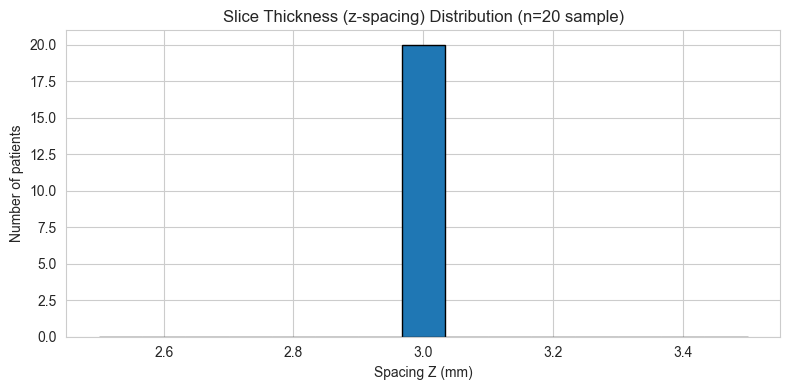

In [11]:
random.seed(42)
sample_patients = random.sample(matched_ids, 20)

results = []
for pid in tqdm(sample_patients, desc='Reading CT series'):
    patient_dir = RADIOMICS_DIR / pid
    series_by_mod = find_series_dirs(patient_dir)
    ct_series_dir = series_by_mod['CT'][0][0]

    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(str(ct_series_dir))
    reader.SetFileNames(dicom_names)
    image = reader.Execute()

    sx, sy, sz = image.GetSize()
    spx, spy, spz = image.GetSpacing()
    results.append({'PatientID': pid, 'size_x': sx, 'size_y': sy, 'size_z': sz,
                     'spacing_x': spx, 'spacing_y': spy, 'spacing_z': spz})

scan_chars = pd.DataFrame(results)

print("Image size summary (voxels):")
display(scan_chars[['size_x', 'size_y', 'size_z']].describe())

print("\nVoxel spacing summary (mm):")
display(scan_chars[['spacing_x', 'spacing_y', 'spacing_z']].describe())

print("\nMost common (rounded to 2dp) voxel spacings (x, y, z) in this sample:")
print(scan_chars[['spacing_x', 'spacing_y', 'spacing_z']].round(2).value_counts())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scan_chars['spacing_z'], bins=15, edgecolor='black')
ax.set_title(f'Slice Thickness (z-spacing) Distribution (n={len(scan_chars)} sample)')
ax.set_xlabel('Spacing Z (mm)')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.show()

In [12]:
rtstruct_records = []
for pid in tqdm(matched_ids, desc='Scanning RTSTRUCT availability'):
    patient_dir = RADIOMICS_DIR / pid
    series_by_mod = find_series_dirs(patient_dir)

    has_rtstruct = 'RTSTRUCT' in series_by_mod
    roi_names = []
    if has_rtstruct:
        rt_file = next(series_by_mod['RTSTRUCT'][0][0].glob('*.dcm'))
        rt = pydicom.dcmread(rt_file)
        roi_names = [roi.ROIName for roi in rt.StructureSetROISequence]

    has_gtv = any('gtv' in n.lower() for n in roi_names)

    rtstruct_records.append({
        'PatientID': pid,
        'has_rtstruct': has_rtstruct,
        'n_rois': len(roi_names),
        'has_gtv': has_gtv,
        'roi_names': '; '.join(roi_names),
    })

rtstruct_df = pd.DataFrame(rtstruct_records)

n_rtstruct = rtstruct_df['has_rtstruct'].sum()
n_gtv = rtstruct_df['has_gtv'].sum()
print(f"Patients with RTSTRUCT available: {n_rtstruct} / {len(rtstruct_df)}")
print(f"Patients with a GTV-like (tumour) ROI: {n_gtv} / {len(rtstruct_df)}")

Scanning RTSTRUCT availability:   0%|          | 0/422 [00:00<?, ?it/s]

Patients with RTSTRUCT available: 422 / 422
Patients with a GTV-like (tumour) ROI: 422 / 422


## Save and Summarise

In [13]:
OUT_DIR = Path('../../data/processed/cohort')
OUT_DIR.mkdir(parents=True, exist_ok=True)

matched_cohort.to_csv(OUT_DIR / 'radiomics_matched_cohort.csv', index=False)
rtstruct_df.to_csv(OUT_DIR / 'radiomics_rtstruct_availability.csv', index=False)

print(f"radiomics_matched_cohort.csv:        {len(matched_cohort)} rows")
print(f"radiomics_rtstruct_availability.csv: {len(rtstruct_df)} rows")

radiomics_matched_cohort.csv:        422 rows
radiomics_rtstruct_availability.csv: 422 rows


## Summary

**Cohort size and matching**
- **422 patients** in NSCLC-Radiomics, all with a 1 study folder containing CT + RTSTRUCT (+ SEG for 421/422; `LUNG1-128` lacks a SEG series but still has CT + RTSTRUCT)
- `Lung1_clinical.csv` also has 422 rows, and the match against imaging folders is **422/422 (100%)** — every clinical record has a matching imaging folder and vice versa. `radiomics_matched_cohort.csv` (422 rows) saved.

**TNM stage distribution — class imbalance to flag for Week 5**
- **T stage**: T2 (156), T4 (117), T1 (93), T3 (53), T5 (2, non-standard — likely a data-entry artifact, worth checking against TCIA docs), 1 missing
- **N stage**: N0 (170), N2 (141), N3 (85), N1 (23), N4 (3, non-standard)
- **M stage**: heavily skewed — M0 (417), M3 (4, non-standard), M1 (1) — almost no metastatic cases
- **Overall stage**: **no Stage IV present at all**. IIIb (176, 41.7%) and IIIa (112, 26.5%) dominate; I (93, 22.0%) and II (40, 9.5%, smallest class) are underrepresented. → Stratified splits by `Overall.Stage` are essential, and Stage II / any M1 cases should be preserved across train/val/test rather than risk being dropped entirely from a small split.

**Histology and survival**
- Histology: squamous cell carcinoma (152), large cell (114), NOS (63), adenocarcinoma (51), **missing for 42 patients (~10%)**
- Survival: 373/422 (88%) deceased, 49/422 (12%) alive — survival is not a balanced label if used downstream

**Scan geometry (n=20 sample, seed=42)**
- All sampled scans are **512 × 512 in-plane**; slice count (`size_z`) ranges 82–297, median ~125, with **134 slices being the single most common value**
- Voxel spacing is essentially uniform: **(0.9766–0.9770, 0.9766–0.9770, 3.0) mm** — i.e. ~1×1mm in-plane, 3mm slice thickness, across every sampled patient
- Sample patient `LUNG1-001`: 512×512×134 @ (0.977, 0.977, 3.0) mm, HU range −1024 to 3034

**RTSTRUCT availability — excellent ground truth coverage**
- **422/422 (100%)** of matched patients have an RTSTRUCT file
- **422/422 (100%)** have at least one GTV-like ROI (e.g. `GTV-1`, sometimes `gtv-2`/`gtv-3` for multifocal disease); typical ROI sets also include `Lung-Left`, `Lung-Right`, `Heart`, `Esophagus`, `Spinal-Cord` (1–11 ROIs per patient, median 6)
- `radiomics_rtstruct_availability.csv` (422 rows) saved

**Recommendations for next steps**

(a) **Vision Agent sanity-check sample (8 patients)** — all have matched clinical labels, RTSTRUCT + GTV available, and standard 512×512 dimensions with the modal spacing (0.9766–0.977, ·, 3.0) mm:
  - `LUNG1-001` (already inspected in detail above; 134 slices)
  - `LUNG1-013`, `LUNG1-303`, `LUNG1-378` (also exactly 134 slices)
  - `LUNG1-328` (132), `LUNG1-380` (131), `LUNG1-048` (135), `LUNG1-280` (130)
  These span a narrow, representative slice-count range (130–135) while covering different `Overall.Stage` values once cross-checked against `radiomics_matched_cohort.csv`.

(b) **Target voxel spacing for preprocessing**: resample to **(1.0, 1.0, 3.0) mm**. The native in-plane spacing (0.9766–0.977 mm) is already close to 1mm and near-universal across the cohort, so this normalises the small per-scanner variation with minimal interpolation. Slice thickness (3.0mm) is uniform across every sampled scan, so there's no need to resample in z for this phase. If the Vision Agent later needs more isotropic volumes for finer GTV boundary delineation (e.g. a 3D nnU-Net-style model), a secondary (1.0, 1.0, 1.0) mm pipeline can be added — but note this triples the slice count and data volume.